## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns
import shap
from itertools import product
import h5py
import io
from PIL import Image

# Sklearn imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, cross_validate
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score, precision_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.base import clone

# Imbalanced-learn imports
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier

import pickle
import json
import os

import warnings
warnings.filterwarnings('ignore')

In [2]:
class CFG:
    colab = False  # Cambiar a True si se usa Colab
    Root = '..' if not colab else '/content/drive/MyDrive/PAI'
    path_df_imputed = f'{Root}/BaseDatos/df_imputed_with_original.csv'
    path_df_imputed_corrected = f'{Root}/BaseDatos/df_imputed_corrected.csv'
    elements_list = ["Nitrogen", "Phosphorus", "Potassium"]
    productivity_vars = ["Plant_Height (cm)", "Number of Flowers", 'Number of Harvested Fruits', 
                         'Weight of Harvested Fruits (Kg)','Fruit Height (mm)', 'Fruit Diameter (mm)']
    model_list = ['RF', 'SVM', 'MLP', 'KNN']
    include_prod = False  # Para incluir variables de productividad


    # NOTE: Cambiar el siguiente flag segun el tipo de entrenamiento
    individual_train = False # Para entrenar con los elementos por separado
    cuartiles_train = True

    # NOTE: Cambiar el siguiente path segun include prod
    if include_prod:
        if cuartiles_train:
            class_path = f'{Root}/Resultados/classification_cuartiles_include_prod/'
        else:
            class_path = f'{Root}/Resultados/classification_include_prod/'
    else:
        if cuartiles_train:
            class_path = f'{Root}/Resultados/classification_cuartiles_exclude_prod/'
        else:
            class_path = f'{Root}/Resultados/classification_exclude_prod/'


    if individual_train:
        path_pkl_results_classification = f"{class_path}class_results_individual_elements.pkl"
    elif cuartiles_train:
        path_pkl_results_classification = f"{class_path}class_models_cuartiles.pkl"
    else:
        path_pkl_results_classification = f"{class_path}all_classification_models.pkl"

    treat_quantiles_path = f'{Root}/Resultados/treatments_quantile_unified.json'

## 2. Funciones Auxiliares

In [3]:
if CFG.colab:
    from google.colab import drive
    drive.mount('/content/drive')

### 2.1 Funciones de Codificación de Clases

In [4]:
def codificar_clase(n, p, k):
    """Codificación base de 8 clases basada en combinaciones de nutrientes."""
    if n == 1 and p == 1 and k == 1:
        return 7
    elif n == 1 and p == 1:
        return 4
    elif n == 1 and k == 1:
        return 5
    elif p == 1 and k == 1:
        return 6
    elif n == 1:
        return 1
    elif p == 1:
        return 2
    elif k == 1:
        return 3
    else:
        return 0

def codificar_clase_personalizada(n, p, k, n_clases):
    """Codificación personalizada para 2-5 clases."""
    clase_base = codificar_clase(n, p, k)
    if n_clases == 2:
        return 1 if clase_base in [4, 5, 6, 7] else 0
    elif n_clases == 3:
        if clase_base in [1, 2, 3]:
            return 1
        elif clase_base in [4, 5, 6, 7]:
            return 2
        else:
            return 0
    elif n_clases == 4:
        return sum([n == 1, p == 1, k == 1])
    elif n_clases == 5:
        if n == 1 and p == 1 and k == 1:
            return 3
        elif (n == 1 and p == 1) or (n == 1 and k == 1) or (p == 1 and k == 1):
            return 2
        elif n == 1 or p == 1 or k == 1:
            return 1
        elif n == 0 and p == 0 and k == 0:
            return 0
        else:
            return 4
    else:
        return clase_base

def codificar_clase_6(c):
    """Agrupación para 6 clases."""
    if c == 0:
        return 0
    elif c == 1:
        return 1
    elif c in [2, 3]:
        return 2
    elif c in [4, 5]:
        return 3
    elif c == 6:
        return 4
    elif c == 7:
        return 5

def codificar_clase_7(c):
    """Agrupación para 7 clases."""
    if c in [5, 6]:
        return 5
    elif c == 7:
        return 6
    else:
        return c

def codificar_clase_nk_9(n, k):
    """Codificación de 9 clases basada en N y K (ignora P)."""
    if n not in [0, 1, 2] or k not in [0, 1, 2]:
        return None
    return 3 * n + k

def codificar_clase_agrupada(n, p, k, n_clases):
    """Función principal de codificación según número de clases."""
    base = codificar_clase(n, p, k)
    if n_clases == 5:
        return codificar_clase_personalizada(n, p, k, 5)
    elif n_clases == 6:
        return codificar_clase_6(base)
    elif n_clases == 7:
        return codificar_clase_7(base)
    elif n_clases == 8:
        return base
    elif n_clases == 9:
        return codificar_clase_nk_9(n, k)
    else:
        return codificar_clase_personalizada(n, p, k, n_clases)

def codificar_clase_individual(df, element):
    if element not in CFG.elements_list:
        raise ValueError(f"Elemento '{element}' no válido. Debe ser uno de {CFG.elements_list}.")
    return df[element].copy()

def codificar_clase_cuartiles(df, filter_data=True):
    """
    Codifica clases basado en cuartiles de productividad.
    
    Args:
        df: DataFrame con los datos
        filter_data: Si True, elimina tratamientos que no están en Q1 o Q4
    
    Returns:
        Series con las clases codificadas (y DataFrame filtrado si filter_data=True)
    """
    # Leer json con tratamientos asociados a cuartiles
    with open(CFG.treat_quantiles_path, 'r') as f:
        treatments_quantile_unified = json.load(f)
    
    # Crear diccionario inverso: {treatment_num: clase}
    treatment_to_class = {}
    for clase, treatments in treatments_quantile_unified.items():
        for treatment in treatments:
            treatment_to_class[treatment] = int(clase)
    
    if filter_data:
        # Filtrar solo tratamientos Q1 y Q4
        valid_treatments = list(treatment_to_class.keys())
        df_filtered = df[df['Treatment_Num'].isin(valid_treatments)].copy()
        
        # Mapear a clases y remapear a 0 y 1
        y = df_filtered['Treatment_Num'].map(treatment_to_class)
        
        return df_filtered, y
    else:
        # Solo mapear sin filtrar (generará NaN)
        y = df['Treatment_Num'].map(treatment_to_class)
        return y

### 2.2 Funciones para Guardar Gráficos en HDF5

In [5]:
def fig_to_bytes(fig):
    """Convierte una figura de matplotlib a bytes para almacenar en HDF5."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=300, bbox_inches='tight')
    buf.seek(0)
    img_array = np.array(Image.open(buf))
    buf.close()
    plt.close(fig)
    return img_array

def save_to_hdf5(h5_file, group_name, data_dict):
    """Guarda datos en un archivo HDF5.

    Args:
        h5_file: Archivo HDF5 abierto.
        group_name (str): Nombre del grupo donde guardar los datos.
        data_dict (dict): Diccionario con los datos a guardar.
    """
    if group_name in h5_file:
        del h5_file[group_name]

    grp = h5_file.create_group(group_name)

    for key, value in data_dict.items():
        if isinstance(value, np.ndarray):
            grp.create_dataset(key, data=value)
        elif isinstance(value, (int, float)):
            grp.attrs[key] = value
        elif isinstance(value, str):
            grp.attrs[key] = value
        elif isinstance(value, dict):
            grp.attrs[key] = str(value)
        elif value is None:
            pass
        else:
            try:
                grp.attrs[key] = str(value)
            except:
                pass

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Greens):
    """Visualiza una matriz de confusión."""
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.set_title(title, fontsize=14, pad=20)
    plt.colorbar(im, ax=ax)

    tick_marks = np.arange(len(classes))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.set_yticklabels(classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, format(cm[i, j], fmt),
               horizontalalignment="center",
               color="white" if cm[i, j] > thresh else "black")

    ax.set_ylabel('True label', fontsize=12)
    ax.set_xlabel('Predicted label', fontsize=12)
    plt.tight_layout()
    return fig

### 2.3 Función de Preparación de Datos

In [6]:
def preparar_datos(df_imputed, n_clases=3, element="Nitrogen", test_size=0.3, random_state=42):
    """Prepara los datos para entrenamiento.

    Args:
        df_imputed (DataFrame): DataFrame con datos imputados.
        n_clases (int): Número de clases para la codificación.
        element (str): Elemento a utilizar para la codificación individual.
        test_size (float): Proporción del conjunto de prueba.
        random_state (int): Semilla para reproducibilidad.
    Returns:
        tuple: (X_train, X_test, y_train, y_test, feature_names, class_distribution)
    """
    df = df_imputed.copy()
    
    # NOTE: Ahroa se trabajan con 3 clases
    if CFG.individual_train:
        df['target'] = codificar_clase_individual(df, element=element)
    elif CFG.cuartiles_train:
        df, df['target'] = codificar_clase_cuartiles(df, filter_data=True)
    else:
    # NOTE: La siguiente codificación se hacía cuando se trataban 2 a 9 clases
        df['target'] = df.apply(
            lambda row: codificar_clase_agrupada(
                row['Nitrogen'], row['Phosphorus'], row['Potassium'], n_clases
            ), axis=1
        )
    

    # Distribución de clases
    class_distribution = df['target'].value_counts().sort_index()

    # Eliminar columnas no necesarias
    columns_to_drop = ['Nitrogen', 'Phosphorus', 'Potassium', 'target',
                       'Clase_custom', 'Treatment_Num', 'Year', 'Month', 'Day']
    # Eliminar variables de productividad si no se desean incluir
    if not CFG.include_prod:
        columns_to_drop += CFG.productivity_vars
    X = df.drop(columns=columns_to_drop, errors='ignore')
    y = df['target']

    # División de datos
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=test_size, random_state=random_state
    )

    return X_train, X_test, y_train, y_test, X.columns, class_distribution

def extract_X_y_classification(df_imputed, n_clases=3, element="Nitrogen"):
    """
    Extrae las características (X) y las etiquetas (y) del DataFrame para clasificación.

    Args:
        df_imputed (DataFrame): DataFrame con datos imputados.
        n_clases (int): Número de clases para la codificación.
        element (str): Elemento a utilizar para la codificación individual.
    Returns:
        X (DataFrame): Características para el modelo.
        y (Series): Etiquetas de clase.
        class_distribution (Series): Distribución de clases en y.
    """
    df = df_imputed.copy()
    
    # NOTE: Ahroa se trabajan con 3 clases
    if CFG.individual_train:
        df['target'] = codificar_clase_individual(df, element=element)
    elif CFG.cuartiles_train:
        df['target'] = codificar_clase_cuartiles(df)
    else:
    # NOTE: La siguiente codificación se hacía cuando se trataban 2 a 9 clases
        df['target'] = df.apply(
            lambda row: codificar_clase_agrupada(
                row['Nitrogen'], row['Phosphorus'], row['Potassium'], n_clases
            ), axis=1
        )
    

    # Distribución de clases
    class_distribution = df['target'].value_counts().sort_index()

    # Eliminar columnas no necesarias
    columns_to_drop = ['Nitrogen', 'Phosphorus', 'Potassium', 'target',
                       'Clase_custom', 'Treatment_Num', 'Year', 'Month', 'Day']
    # Eliminar variables de productividad si no se desean incluir
    if not CFG.include_prod:
        columns_to_drop += CFG.productivity_vars
    X = df.drop(columns=columns_to_drop, errors='ignore')
    y = df['target']

    return X, y, X.columns, class_distribution

### 2.4 Función de Análisis SHAP

In [7]:
def plot_shap_importance(model, X_train, feature_names, model_type='tree', n_clases=2, title="SHAP Feature Importance", path=None):
    """Genera gráficos de importancia SHAP.

    Args:
        model: Modelo entrenado.
        X_train (DataFrame): Datos de entrenamiento.
        feature_names (list): Nombres de las características.
        model_type (str): 'tree' para TreeExplainer, 'kernel' para KernelExplainer.
                         'kernel' se utiliza para modelos no basados en árboles como SVM, KNN, MLP.
        n_clases (int): Número de clases en el modelo.
        title (str): Título del gráfico.
        path (str): Ruta para guardar el gráfico (sin extensión).
    Returns:
        tuple: (shap_values, explainer, shap_fig, X_df_used)

    """
    X_df = pd.DataFrame(X_train, columns=feature_names)

    if model_type == 'tree':
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_df)
        X_df_used = X_df
    else:  # kernel
        # Usar muestra para KernelExplainer (más rápido)
        background = shap.sample(X_df, min(100, len(X_df)), random_state=42)
        explainer = shap.KernelExplainer(model.predict_proba, background)
        shap_values = explainer.shap_values(background, nsamples=100)
        X_df_used = background

    # Gráfico de barras
    fig = plt.figure(figsize=(12, 6))
    shap.summary_plot(shap_values, X_df_used, feature_names=feature_names,
                     plot_type="bar", show=False)
    plt.title(title, fontsize=14, pad=20)
    plt.xlabel("Mean |SHAP value|", fontsize=12)
    if path:
        plt.savefig(f"{path}_bar.png", dpi=300, bbox_inches='tight')
    plt.tight_layout()

    return shap_values, explainer, fig, X_df_used

### 2.5 Función Principal de Entrenamiento y Evaluación

In [8]:
def initialize_classification_results():
    results = {}
    results["model_params"] = {}
    results["acc"] = {"train": [], "test": []}
    results["precision"] = {"train": [], "test": []}
    results["recall"] = {"train": [], "test": []}
    results["f1_score"] = {"train": [], "test": []}
    return results
def calculate_classification_metrics(y_true, y_pred, average='weighted'):
    """
    Calcula métricas de clasificación
    
    Args:
        y_true: Etiquetas verdaderas
        y_pred: Etiquetas predichas
        average: Tipo de promedio para métricas multiclase
    
    Returns:
        tuple: (accuracy, precision, recall, f1_score)
    """
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average=average, zero_division=0)
    recall = recall_score(y_true, y_pred, average=average, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=average, zero_division=0)
    return acc, precision, recall, f1

def accumulate_classification_results(results, tipo="train", acc=None, precision=None, recall=None, f1=None):
    results["acc"][tipo].append(acc)
    results["precision"][tipo].append(precision)
    results["recall"][tipo].append(recall)
    results["f1_score"][tipo].append(f1)

def print_classification_report(model_name, n_clases, acc_train, acc_test, f1_train, f1_test, best_params, class_dist):
    print(f"\n{'='*60}")
    print(f"  {model_name} - {n_clases} CLASSES")
    print(f"{'='*60}")
    print(f"Best parameters: {best_params}")
    print(f"\nTrain Performance:")
    print(f"  Accuracy: {acc_train:.4f}")
    print(f"  F1 Macro: {f1_train:.4f}")
    print(f"\nTest Performance:")
    print(f"  Accuracy: {acc_test:.4f}")
    print(f"  F1 Macro: {f1_test:.4f}")
    print(f"\nClass Distribution:")
    print(class_dist)

def return_classification_metrics(y_test, y_test_pred):
    acc_test = accuracy_score(y_test, y_test_pred)
    f1_test = f1_score(y_test, y_test_pred, average='micro')
    return acc_test, f1_test

In [9]:
def find_best_model_params(results):
    """
    Encontrar los parametros del modelo que dio mejor resultado en test f1_score
    Args:
        results (dict): Diccionario con resultados acumulados.
    Returns:
        dict: Parámetros del mejor modelo.
    """
    best_f1 = -1
    best_params = None
    for i in range(len(results['f1_score']['test'])):
        if results['f1_score']['test'][i] > best_f1:
            best_f1 = results['f1_score']['test'][i]
            best_params = results['model_params'][i]
    return best_params

def strip_pipeline_prefix(params):
    """
    Remove pipeline prefixes (like 'clf__') from parameter names.
    Args:
        params (dict): Parameters with pipeline prefixes.
    Returns:
        dict: Parameters with prefixes removed.
    """
    stripped = {}
    for key, value in params.items():
        # Remove any prefix ending with '__'
        if '__' in key:
            new_key = key.split('__', 1)[-1]  # Take everything after the first '__'
            stripped[new_key] = value
        else:
            stripped[key] = value
    return stripped

def train_test_class_nested(df_imputed, n_clases, model_name, model_config, element = "Nitrogen",
                              usar_smote=True, mostrar_graficos=True, calcular_shap=True,
                              h5_file=None,
                              dir_path= "../"):
    # Preparar datos
    X, y, feature_names, class_distribution = extract_X_y_classification(
        df_imputed, n_clases=n_clases, element=element
    )
    
    
    skf_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    skf_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    results = initialize_classification_results()
    
    for fold_idx, (train_index, val_index) in enumerate(skf_outer.split(X, y)):
        X_train, X_test = X.iloc[train_index], X.iloc[val_index]
        y_train, y_test = y.iloc[train_index], y.iloc[val_index]

        # Pipeline (evita data leakage)
        if usar_smote:
            pipeline = ImbPipeline([
                ('scaler', StandardScaler()),
                ('smote', SMOTE(random_state=42)),
                ('clf', model_config['estimator'])
            ])
        else:
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('clf', model_config['estimator'])
            ])
        
        # GridSearchCV con CV interno
        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=model_config['param_grid'],
            cv=skf_inner,
            scoring='f1_micro',
            n_jobs=-1,
            verbose=1,
            return_train_score=True
        )
        
        grid.fit(X_train, y_train)
        
        # Extraer métricas del INNER CV
        best_idx = grid.best_index_
        inner_train_f1 = grid.cv_results_['mean_train_score'][best_idx]        
        # 8. Evaluar en outer fold
        y_pred_test = grid.predict(X_test)
        
        # Usar tus funciones existentes
        
        avg = "weighted" if n_clases != None else "micro" 
        test_acc, test_prec, test_rec, test_f1 = calculate_classification_metrics(
            y_test, y_pred_test, average=avg
        )
        
        # Acumular con tu función (solo test, train viene del CV interno)
        accumulate_classification_results(
            results, "train", inner_train_f1, None, None, inner_train_f1
        )
        accumulate_classification_results(
            results, "test", test_acc, test_prec, test_rec, test_f1
        )
        
        # Guardar parámetros
        results["model_params"][fold_idx] = grid.best_params_
    
    
    if CFG.individual_train:
        model_path =  f"{dir_path}/models/{model_name.replace(' ', '_')}_nclases_{3}_{element}_params.pkl"
    elif CFG.cuartiles_train:
        model_path =  f"{dir_path}/models/{model_name.replace(' ', '_')}_nclases_{2}_cuartiles_params.pkl"
    else:
        model_path = f"{dir_path}/models/{model_name.replace(' ', '_')}_nclases_{n_clases}_params.pkl"
    os.makedirs(f"{dir_path}/models", exist_ok=True)
    with open(model_path, 'wb') as f:
        pickle.dump(results['model_params'], f)
    
    best_params = find_best_model_params(results)
    # Strip the 'clf__' prefix from parameters for direct estimator use
    estimator_params = strip_pipeline_prefix(best_params)
    
    # Entrenar modelo FINAL con TODOS los datos
    if usar_smote:
        final_pipeline = ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote', SMOTE(random_state=42)), # TODO: Ver si es correcto usar SMOTE aquí
            ('clf', clone(model_config['estimator']).set_params(**estimator_params))
        ])
    else:
        final_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', clone(model_config['estimator']).set_params(**estimator_params))
        ])
    
    final_pipeline.fit(X, y)
    
    # Guardar PIPELINE completo
    if CFG.individual_train:
        model_path = f"{dir_path}/models/{model_name.replace(' ', '_')}_nclases_3_{element}.pkl"
    elif CFG.cuartiles_train:
        model_path = f"{dir_path}/models/{model_name.replace(' ', '_')}_nclases_2_cuartiles.pkl"
    else:
        model_path = f"{dir_path}/models/{model_name.replace(' ', '_')}_nclases_{n_clases}.pkl"
    
    os.makedirs(f"{dir_path}/models", exist_ok=True)
    with open(model_path, 'wb') as f:
        pickle.dump(final_pipeline, f)
    
    print(f"Model saved: {model_path}")

    # SHAP
    shap_values = None
    X_scaled_df = None
    if calcular_shap:
        
        # Preparar datos completos
        # X_train, X_test, y_train, y_test, feature_names, _ = preparar_datos(
        #     df_imputed, n_clases=n_clases, element=element
        # )
        
        # Preprocesar
        clf = final_pipeline.named_steps['clf']
        scaler = final_pipeline.named_steps['scaler']
        X_scaled = scaler.transform(X)
        
        path_images_shap = f"{dir_path}/{model_name.replace(' ', '_')}/"
        os.makedirs(path_images_shap, exist_ok=True)
        
        shap_values, _, fig_shap, X_scaled_df = plot_shap_importance(
            clf,  # Modelo final
            X_scaled,
            feature_names,
            model_type=model_config['model_type'],
            n_clases=n_clases,
            title=f"SHAP Feature Importance - {model_name}",
            path=f"{path_images_shap}shap"
        )

        if isinstance(shap_values, list):
            # Caso típico multiclase con lista
            for i in range(len(shap_values)):
                print(f"Clase {i} - SHAP summary")
                # Crear figura nueva
                plt.figure()
                shap.summary_plot(shap_values[i], X_scaled_df, plot_type="dot")
        elif len(shap_values.shape) == 2:
            # Caso binario: (n_samples, n_features)
            print("SHAP summary - Binary Classification")
            plt.figure()
            shap.summary_plot(shap_values, X_scaled_df, plot_type="dot")
        else:
            # Caso de array de 3D: (n_samples, n_features, n_classes)
            num_clases = shap_values.shape[-1]
            for i in range(num_clases):
                print(f"Clase {i} - SHAP summary")
                shap.summary_plot(shap_values[..., i], X_scaled_df, plot_type="dot")

        if mostrar_graficos:
            plt.show()

    if CFG.individual_train:
        n_clases_str = f"{3}_{element}"
    elif CFG.cuartiles_train:
        n_clases_str = "2_Quartiles"
    else:
        n_clases_str = str(n_clases)
    resultados_finales = {
        'n_clases': n_clases_str,
        'model_name': model_name, # Nombre del algoritmo
        'accuracy_train': np.mean(results['acc']['train']),
        'accuracy_test': np.mean(results['acc']['test']),
        'f1_train': np.mean(results['f1_score']['train']),
        'f1_test': np.mean(results['f1_score']['test']),
        'accuracy_test_std': np.std(results['acc']['test']),
        'f1_test_std': np.std(results['f1_score']['test']),
    
        'acc_raw' : results['acc'],
        'precision_raw' : results['precision'],
        'best_params': results['model_params'],
        'class_distribution': class_distribution,
        # 'confusion_matrix_train': cm_train,
        # 'confusion_matrix_test': cm_test,
        'grid_search': results['model_params'],
        'shap_values': shap_values,
        'X_scaled_df': X_scaled_df
    }

    return resultados_finales

In [10]:
def train_test_model(df_imputed, n_clases, model_name, model_config, element = "Nitrogen",
                              usar_smote=True, mostrar_graficos=True, calcular_shap=True,
                              h5_file=None,
                              dir_path= "../"):
    """Función principal para entrenar y evaluar un modelo.

    Args:
        df_imputed (DataFrame): DataFrame con datos imputados.
        n_clases (int): Número de clases para la codificación.
        model_name (str): Nombre del modelo.
        model_config (dict): Configuración del modelo (estimator y param_grid).
        element (str): Elemento a utilizar para la codificación individual.
        usar_smote (bool): Si se debe usar SMOTE para balancear clases.
        mostrar_graficos (bool): Si se deben mostrar gráficos de confusión.
        calcular_shap (bool): Si se deben calcular valores SHAP.
        h5_file: Archivo HDF5 abierto para guardar resultados.
    Returns:
        dict: Resultados del entrenamiento y evaluación del modelo.
    """
    # Preparar datos
    X_train, X_test, y_train, y_test, feature_names, class_dist = preparar_datos(
        df_imputed, n_clases, element=element
    )

    # Construir pipeline
    if usar_smote:
        pipeline_steps = [
            ('scaler', StandardScaler()),
            ('smote', SMOTE(random_state=42)),
            ('clf', clone(model_config['estimator']))
        ]
        pipe = ImbPipeline(pipeline_steps)
    else:
        pipeline_steps = [
            ('scaler', StandardScaler()),
            ('clf', clone(model_config['estimator']))
        ]
        pipe = Pipeline(pipeline_steps)

    # Grid Search
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(pipe, model_config['param_grid'], cv=cv,
                       scoring='f1_micro', n_jobs=-1, verbose=2,
                       return_train_score=True)
    grid.fit(X_train, y_train)

    # Métricas train (usando cross-validation)
    nested_score = cross_validate(
        grid.best_estimator_, X=X_train, y=y_train,
        cv=cv, scoring=['f1_micro', 'f1_macro', 'accuracy'],
        return_train_score=True
    )
    acc_train = np.mean(nested_score['train_accuracy'])
    f1_train = np.mean(nested_score['train_f1_micro'])
    # Test 
    y_test_pred = grid.predict(X_test)

    # Métricas test
    acc_test, f1_test = return_classification_metrics(
        y_test, y_test_pred
    )

    # Classification Report
    # Classification Report
    class_report = classification_report(y_test, y_test_pred)
    print(class_report)
    class_report_dict = classification_report(y_test, y_test_pred, output_dict=True)

    # Matrices de confusión
    cm_test = confusion_matrix(y_test, y_test_pred)

    #Guardar modelo
    #model_path = f"../Resultados/classification/models/{model_name.replace(' ', '_')}_nclases_{n_clases}.pkl"
    #Revisar si el directorio existe

    if CFG.individual_train:
        model_path =  f"{dir_path}/models/{model_name.replace(' ', '_')}_nclases_{3}_{element}.pkl"
    elif CFG.cuartiles_train:
        model_path =  f"{dir_path}/models/{model_name.replace(' ', '_')}_nclases_{2}_cuartiles.pkl"
    else:
        model_path = f"{dir_path}/models/{model_name.replace(' ', '_')}_nclases_{n_clases}.pkl"
    os.makedirs(f"{dir_path}/models", exist_ok=True)
    with open(model_path, 'wb') as f:
        pickle.dump(grid.best_estimator_, f)

    # Imprimir resultados
    print_classification_report(model_name, n_clases, acc_train, acc_test, f1_train, f1_test, grid.best_params_, class_dist)

    # # Gráficos de confusión
    # fig_cm_train = plot_confusion_matrix(cm_train, classes=np.unique(y_train),
    #                     title=f"{model_name} Train - {n_clases} classes")
    if mostrar_graficos:
        plt.show()

    fig_cm_test = plot_confusion_matrix(cm_test, classes=np.unique(y_test),
                        title=f"{model_name} Test - {n_clases} classes")
    if mostrar_graficos:
        plt.show()

    # SHAP
    shap_values = None
    fig_shap = None
    X_scaled_df = None
    if calcular_shap:
        scaler = grid.best_estimator_.named_steps['scaler']
        clf = grid.best_estimator_.named_steps['clf']
        X_train_scaled = scaler.transform(X_train)

        #revisar si existe la carpeta
        path_images_shap = f"{dir_path}/{model_name.replace(' ', '_')}/"
        os.makedirs(path_images_shap, exist_ok=True)

        shap_values, _, fig_shap, X_scaled_df = plot_shap_importance(
            clf, X_train_scaled, feature_names,
            model_type=model_config['model_type'],
            n_clases=n_clases,
            title=f"SHAP Feature Importance - {model_name} ({n_clases} classes)",
            path=f"{path_images_shap}{n_clases}_clases_shap"
        )

        if isinstance(shap_values, list):
            # Caso típico multiclase con lista
            for i in range(len(shap_values)):
                print(f"Clase {i} - SHAP summary")
                # Crear figura nueva
                plt.figure()
                shap.summary_plot(shap_values[i], X_scaled_df, plot_type="dot")
        elif len(shap_values.shape) == 2:
            # Caso binario: (n_samples, n_features)
            print("SHAP summary - Binary Classification")
            plt.figure()
            shap.summary_plot(shap_values, X_scaled_df, plot_type="dot")
        else:
            # Caso de array de 3D: (n_samples, n_features, n_classes)
            num_clases = shap_values.shape[-1]
            for i in range(num_clases):
                print(f"Clase {i} - SHAP summary")
                shap.summary_plot(shap_values[..., i], X_scaled_df, plot_type="dot")

        if mostrar_graficos:
            plt.show()

    if CFG.individual_train:
        n_clases_str = f"{3}_{element}"
    elif CFG.cuartiles_train:
        n_clases_str = "2_Quartiles"
    else:
        n_clases_str = str(n_clases)
    resultados = {
        'n_clases': n_clases_str,
        'model_name': model_name,
        'accuracy_train': acc_train,
        'accuracy_test': acc_test,
        'f1_train': f1_train,
        'f1_test': f1_test,
        'best_params': grid.best_params_,
        'class_distribution': class_dist,
        'classification_report': class_report_dict,
        'confusion_matrix_test': cm_test,
        'grid_search': grid,
        'shap_values': shap_values,
        'X_scaled_df': X_scaled_df
    }

    return resultados

### 2.6 Función para Comparar Modelos

In [11]:
def compare_classification_models(resultados_dict):
    """Compara el rendimiento de diferentes modelos.

    Args:
        resultados_dict (dict):
            Diccionario con resultados de cada modelo
            Formato: {model_name: [lista de resultados por n_clases]}
    """
    def plot_comparative_bars(resultados_dict: dict, metric: str):

        if CFG.individual_train:
            n_classes = CFG.elements_list
        elif CFG.cuartiles_train:
            n_classes = ["Quartiles"]
        else:
            n_classes = np.arange(2, 10)

        fig, ax = plt.subplots(figsize=(10, 6))
        width = 0.15  # the width of the bars
        n_models = len(resultados_dict)
        multiplier = 0
        x = np.arange(len(n_classes))
        for model_name, resultados in resultados_dict.items():
            metrics = [resultados[i][metric] for i in range(len(resultados))]

            # Center the bars by offsetting from the middle
            offset = width * (multiplier - n_models / 2 + 0.5)
            rects = ax.bar(x + offset, metrics, width, label=model_name, 
                          edgecolor='black', linewidth=0.8)
            #ax.bar_label(rects, padding=8,  fmt='{:.3f}', rotation = 45)

            # Poner Etiquetas
            for rect in rects:
                height = rect.get_height()
                txt = ax.text(rect.get_x() + rect.get_width()/2,
                        height/2,  # Posición en el centro de la barra
                        f'{height:.3f}',
                        ha='center',  # alineación horizontal centrada
                        va='center',  # alineación vertical centrada
                        rotation=90,
                        fontsize=10,
                        fontweight='bold',
                        color='white')
                txt.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                                     path_effects.Normal()])

            multiplier += 1

        # Add some text for labels, title and custom x-axis tick labels, etc.
        ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=12)
        ax.set_title(f'Comparison of Models by {metric.replace("_", " ").title()}', fontsize=14, pad=15)
        ax.set_xticks(x, n_classes)
        if CFG.individual_train:
            ax.set_xlabel('Fertilizer Element', fontsize=12)
        elif CFG.cuartiles_train:
            ax.set_xlabel('Model', fontsize=12)
        else:
            ax.set_xlabel('Number of Classes', fontsize=12)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.set_ylim(0, 1)
        # Save figure
        plt.tight_layout()
        plt.savefig(f'{CFG.class_path}comparison_{metric}.png', dpi=300, bbox_inches='tight')
        plt.show()

    # Gráficos comparativos
    plot_comparative_bars(resultados_dict, 'accuracy_test')
    plot_comparative_bars(resultados_dict, 'f1_test')
    # Tabla resumen
    print("\n" + "="*80)
    print("SUMMARY OF BEST RESULTS BY MODEL")
    print("="*80)
    for model_name, resultados in resultados_dict.items():
        df_temp = pd.DataFrame(resultados)
        best_idx = df_temp['f1_test'].idxmax()
        best_result = df_temp.iloc[best_idx]
        print(f"\n{model_name}:")
        if CFG.individual_train:
            print(f"  Best element: {best_result['n_clases']}")
        else:
            print(f"  Best n_classes: {best_result['n_clases']}")
        print(f"  Accuracy: {best_result['accuracy_test']:.4f}")
        print(f"  F1 Macro: {best_result['f1_test']:.4f}")

In [12]:
def save_model(model, path):
    with open(path, 'wb') as f:
        pickle.dump(model, f)
def load_model(path):
    with open(path, 'rb') as f:
        loaded_model = pickle.load(f)
    return loaded_model

## 3. Cargar Datos

In [96]:
# from google.colab import drive
# drive.mount('/content/drive')

In [13]:
def clean_feature_names(feature_names):
    """Remove characters that XGBoost doesn't allow in feature names."""
    cleaned = []
    for name in feature_names:
        # Replace brackets with parentheses or underscores
        cleaned_name = name.replace('[', ' (').replace(']', ')').replace('<', '_lt_')
        cleaned.append(cleaned_name)
    return cleaned

In [14]:
# Cargar datos imputados
df_imputed = pd.read_csv(CFG.path_df_imputed_corrected)
print(f"Dataset shape: {df_imputed.shape}")
df_imputed.columns = clean_feature_names(df_imputed.columns)
print(f"\nColumns: {list(df_imputed.columns)}")
df_imputed.tail()

Dataset shape: (2292, 33)

Columns: ['Plant_Height (cm)', 'Chlorophyll (SPAD)', 'Number of Flowers', 'Number of Harvested Fruits', 'Weight of Harvested Fruits (Kg)', 'Fruit Height (mm)', 'Sap pH', 'Sap K (ppm)', 'Sap Ca (ppm)', 'Sap Na (ppm)', 'Sap NO3 (ppm)', 'Sap Conductivity (mS/cm)', 'Soil pH Horiba', 'Soil K Horiba (ppm)', 'Soil Ca Horiba (ppm)', 'Soil Na Horiba (ppm)', 'Soil NO3 Horiba (ppm)', 'Soil Conductivity Horiba (mS/cm)', 'Fruit Diameter (mm)', '7in1_Ph (pH)', '7in1_Moisture (%RH)', '7in1_S_Temperature (C)', 'Air_sensor_Temperature (C)', 'Air_sensor_Humidity (%RH)', '7in1_Conductivity (mS/cm)', 'Pynamometer_Radiation (W/m2)', 'Nitrogen', 'Phosphorus', 'Potassium', 'Year', 'Month', 'Day', 'Treatment_Num']


,Plant_Height (cm),Chlorophyll (SPAD),Number of Flowers,Number of Harvested Fruits,Weight of Harvested Fruits (Kg),Fruit Height (mm),Sap pH,Sap K (ppm),Sap Ca (ppm),Sap Na (ppm),...,Air_sensor_Humidity (%RH),7in1_Conductivity (mS/cm),Pynamometer_Radiation (W/m2),Nitrogen,Phosphorus,Potassium,Year,Month,Day,Treatment_Num
2287,171.0,57.33,23.6,1.0,0.180,70.3,5.438,3580.0,385.4,49.60,...,79.64,0.1307,271.1,2.0,2.0,2.0,2024.0,12.0,4.0,27.0
2288,167.2,57.19,23.4,7.0,0.706,60.7,5.438,3230.0,263.2,49.70,...,68.08,0.1242,262.7,2.0,2.0,2.0,2024.0,12.0,4.0,27.0
2289,136.6,60.03,14.1,6.0,0.829,70.2,5.506,3490.0,226.0,57.10,...,63.30,0.0280,269.0,0.0,0.0,1.0,2024.0,12.0,4.0,4.0
2290,64.6,50.57,7.7,2.0,0.174,50.7,5.667,3330.0,223.6,50.35,...,53.07,0.2098,347.2,0.0,0.0,1.0,2024.0,12.0,4.0,4.0
2291,180.5,59.77,19.7,1.0,0.150,70.1,5.594,3480.0,181.2,57.40,...,64.70,0.0144,263.5,0.0,0.0,1.0,2024.0,12.0,4.0,4.0


## 4. Configuración de Modelos

In [99]:
# Configuración de modelos
MODELS_CONFIG = {
    'RF': {
        'estimator': RandomForestClassifier(random_state=42),
        'param_grid': {
            'clf__n_estimators': [50, 100, 200, 300],
            'clf__max_depth': [10, 20 , 30, 40, 50],
        },
        'model_type': 'tree'
    },
    'SVM': {
        'estimator': SVC(probability=True, random_state=42),
        'param_grid': {
            'clf__C': [0.1, 1, 10, 100, 300],
            'clf__kernel': ['rbf'],
            'clf__gamma': ['auto', 0.01, 0.1, 1, 10]
        },
        'model_type': 'kernel'
    },
    'KNN': {
        'estimator': KNeighborsClassifier(),
        'param_grid': {
            'clf__n_neighbors': [2, 3, 5, 7, 9]
        },
        'model_type': 'kernel'
    },
    'MLP': {
        'estimator': MLPClassifier(max_iter=500, random_state=42),
        'param_grid': {
            'clf__hidden_layer_sizes': [(50,), (100,), (200,), (100, 50)],
            'clf__alpha': [0.00001, 0.0001, 0.001]
        },
        'model_type': 'kernel'
    }
    ,
    'XGB': {
        'estimator': XGBClassifier(
            random_state=42,
            eval_metric='mlogloss' # Ojo cambiar a binary:logistic si es binario
        ),
        'param_grid': {
            'clf__n_estimators': [200, 300, 400],
            'clf__max_depth': [5, 7, 10],
            'clf__learning_rate': [0.01, 0.1, 0.2, 0.3],
            'clf__subsample': [0.8, 1.0],
            'clf__colsample_bytree': [0.8, 1.0]
        },
        'model_type': 'tree'
    }
        
}

# Rango de número de clases a evaluar
N_CLASES_RANGE = range(2, 10)

In [100]:
list(MODELS_CONFIG.keys())

['RF', 'SVM', 'KNN', 'MLP', 'XGB']

## **5. Entrenamiento de Modelos**

### 5.1 Train 3 Modelos (N,P,K) Individual

Se entrena para diferenciar la cantidad de fertilizante en cada elemento, un modelo por aparte

Deficiencia, adecuado, exceso

Categorías Modelo Nitrógeno: N0,N1,N2

Categorías Modelo Fósforo: P0,P1,P2

Categorías Modelo Potacio: K0,K1,K2

In [ ]:
from joblib import Parallel, delayed

# Función wrapper para entrenar un modelo con un elemento específico
def entrenar_modelo_por_elemento(model_name, model_config, df_imputed, element):
    """Entrena un modelo para un elemento específico."""
    dir_path = f"{CFG.class_path}{model_name.replace(' ', '_')}/"
    # asegurar que exista la ruta de resultados
    os.makedirs(dir_path, exist_ok=True)  # exist_ok=True evita el error si ya existe

    # NOTE: It can be changed by 'train_test_model'
    resultado = train_test_model(
        df_imputed=df_imputed,
        n_clases=None,  # No utilizar para este experimento
        model_name=model_name,
        model_config=model_config,
        element=element,
        usar_smote=False,
        mostrar_graficos=True,
        calcular_shap=True,
        dir_path=dir_path
    )
    return (model_name, element, resultado)

# Ejecutar todos los modelos y elementos en paralelo
if CFG.individual_train:
    all_results_list = Parallel(n_jobs=-1, verbose=10)(
        delayed(entrenar_modelo_por_elemento)(
            model_name=model_name,
            model_config=model_config,
            df_imputed=df_imputed,
            element=element
        ) for model_name, model_config in zip(list(MODELS_CONFIG.keys()), [MODELS_CONFIG[m] for m in MODELS_CONFIG.keys()])
        for element in CFG.elements_list
    )

    # Organizar resultados en estructura de diccionario
    all_results = {}
    for model_name, element, resultado in all_results_list:
        if model_name not in all_results:
            all_results[model_name] = []
        all_results[model_name].append(resultado)

    print(f"Total de combinaciones: {len(all_results_list)}")


    path_classification_results = CFG.path_pkl_results_classification
    with open(path_classification_results, 'wb') as pkl_file:
        pickle.dump(all_results, pkl_file)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of  15 | elapsed:  5.4min remaining: 34.9min
[Parallel(n_jobs=-1)]: Done   4 out of  15 | elapsed:  7.0min remaining: 19.2min
[Parallel(n_jobs=-1)]: Done   6 out of  15 | elapsed: 20.4min remaining: 30.6min
[Parallel(n_jobs=-1)]: Done   8 out of  15 | elapsed: 24.6min remaining: 21.5min
[Parallel(n_jobs=-1)]: Done  10 out of  15 | elapsed: 38.6min remaining: 19.3min
[Parallel(n_jobs=-1)]: Done  12 out of  15 | elapsed: 45.8min remaining: 11.4min
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed: 77.4min finished


Total de combinaciones: 15


### 5.2 Train Cuartiles (2 Categorías)

Se entrena para diferenciar los fertilizantes de los tratamientos Q1 vs Q4

In [80]:
from joblib import Parallel, delayed

# Función wrapper para entrenar un modelo con un elemento específico
def entrenar_modelo_por_elemento(model_name, model_config, df_imputed, element):
    """Entrena un modelo para un elemento específico."""
    dir_path = f"{CFG.class_path}{model_name.replace(' ', '_')}/"
    # asegurar que exista la ruta de resultados
    os.makedirs(dir_path, exist_ok=True)  # exist_ok=True evita el error si ya existe

    # NOTE: It can be changed by 'train_test_model'
    resultado = train_test_model(
        df_imputed=df_imputed,
        n_clases=None,  # No utilizar para este experimento
        model_name=model_name,
        model_config=model_config,
        element=element,
        usar_smote=False,
        mostrar_graficos=True,
        calcular_shap=True,
        dir_path=dir_path
    )
    return (model_name, element, resultado)

if CFG.cuartiles_train:
    all_results_list = Parallel(n_jobs=-1, verbose=10)(
        delayed(entrenar_modelo_por_elemento)(
            model_name=model_name, #Nombre del algoritmo
            model_config=model_config,
            df_imputed=df_imputed,
            element=None
        ) for model_name, model_config in zip(list(MODELS_CONFIG.keys()), [MODELS_CONFIG[m] for m in MODELS_CONFIG.keys()])
    )

    # Organizar resultados en estructura de diccionario
    all_results = {}
    for model_name, element, resultado in all_results_list:
        if model_name not in all_results:
            all_results[model_name] = []
        all_results[model_name].append(resultado)

    print(f"Total de combinaciones: {len(all_results_list)}")


    path_classification_results = CFG.path_pkl_results_classification
    with open(path_classification_results, 'wb') as pkl_file:
        pickle.dump(all_results, pkl_file)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  3.9min remaining:  5.9min
[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed:  5.4min remaining:  3.6min


Total de combinaciones: 5


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  5.8min finished


## 6. Comparación de Resultados

In [15]:
with open(CFG.path_pkl_results_classification, 'rb') as pkl_file:
    todos_los_resultados = pickle.load(pkl_file)


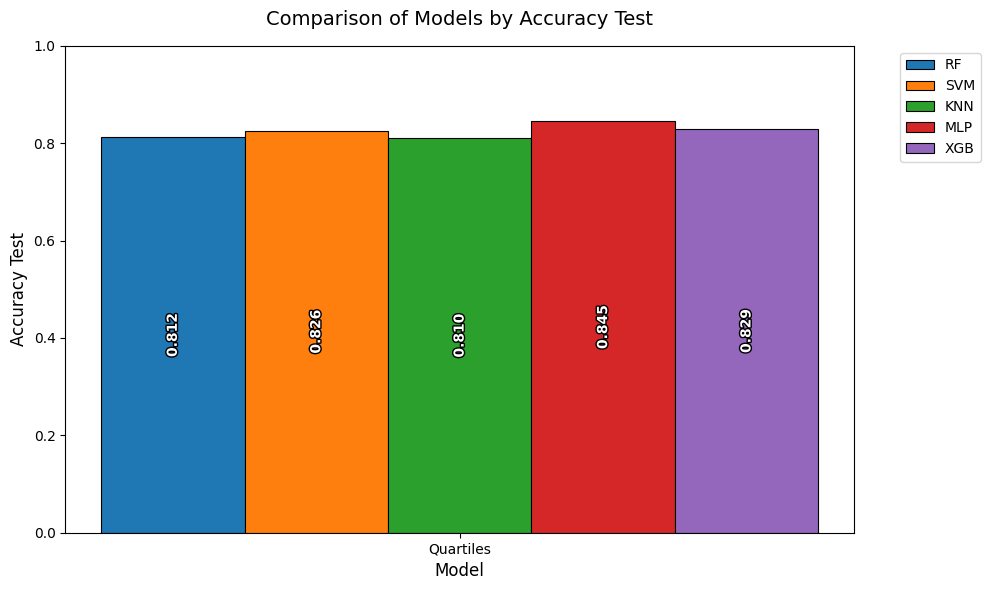

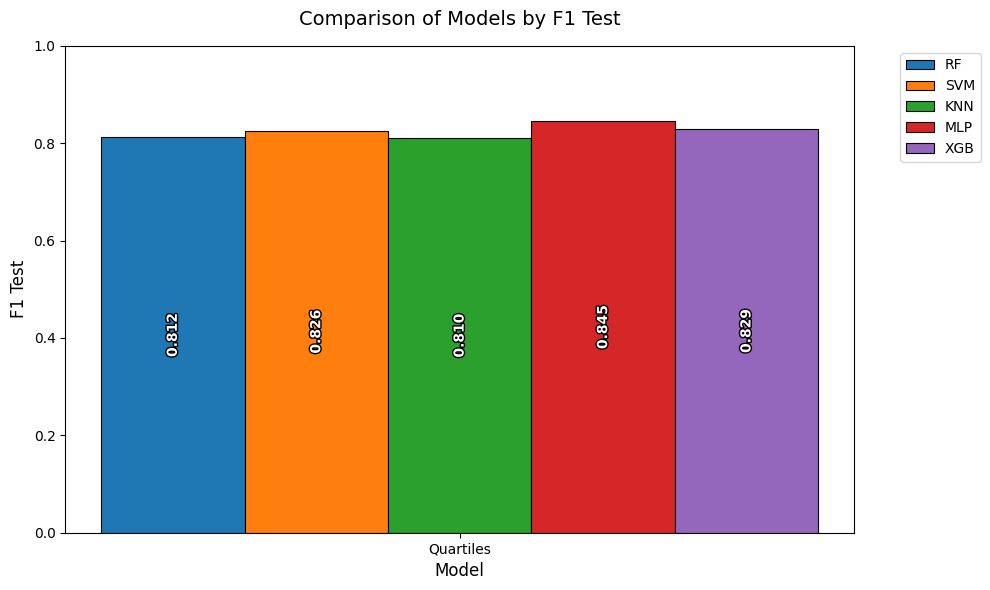


SUMMARY OF BEST RESULTS BY MODEL

RF:
  Best n_classes: 2_Quartiles
  Accuracy: 0.8125
  F1 Macro: 0.8125

SVM:
  Best n_classes: 2_Quartiles
  Accuracy: 0.8261
  F1 Macro: 0.8261

KNN:
  Best n_classes: 2_Quartiles
  Accuracy: 0.8098
  F1 Macro: 0.8098

MLP:
  Best n_classes: 2_Quartiles
  Accuracy: 0.8451
  F1 Macro: 0.8451

XGB:
  Best n_classes: 2_Quartiles
  Accuracy: 0.8288
  F1 Macro: 0.8288


In [16]:
# Consolidar todos los resultados
# todos_los_resultados = {
#     'Random Forest': resultados_rf,
#     'SVM': resultados_svm,
#     'KNN': resultados_knn,
#     'MLP': resultados_mlp
# }


# Comparar modelos
compare_classification_models(todos_los_resultados)

## 7. Visualizar y Exportar Resultados

In [103]:
# load pickle
with open(CFG.path_pkl_results_classification, 'rb') as pkl_file:
    todos_los_resultados = pickle.load(pkl_file)


### 7.1 Reporte Resultados por Clase

In [104]:
# Replace your current cell with:
for model_name, resultados in todos_los_resultados.items():
    print(f"\n{'='*80}")
    print(f"MODEL: {model_name}")
    print(f"{'='*80}")
    for i, resultado in enumerate(resultados):
        print(f"\n--- Configuration {i+1}: {resultado['n_clases']} ---")
        
        # Convert dict to DataFrame for nice display
        df_report = pd.DataFrame(resultado['classification_report']).transpose()
        display(df_report.round(2))
        
        # OR use the custom formatter
        # print(format_classification_report(resultado['classification_report']))


MODEL: RF

--- Configuration 1: 3_Nitrogen ---


,precision,recall,f1-score,support
0.0,0.82,0.76,0.79,228.00
1.0,0.80,0.76,0.78,229.00
2.0,0.77,0.85,0.81,231.00
accuracy,0.79,0.79,0.79,0.79
macro avg,0.79,0.79,0.79,688.00
weighted avg,0.79,0.79,0.79,688.00



--- Configuration 2: 3_Phosphorus ---


,precision,recall,f1-score,support
0.0,0.77,0.83,0.80,228.00
1.0,0.76,0.74,0.75,231.00
2.0,0.77,0.72,0.75,229.00
accuracy,0.77,0.77,0.77,0.77
macro avg,0.77,0.77,0.77,688.00
weighted avg,0.77,0.77,0.77,688.00



--- Configuration 3: 3_Potassium ---


...

,precision,recall,f1-score,support
0.0,0.82,0.75,0.78,228.0
1.0,0.81,0.79,0.80,229.0
2.0,0.77,0.85,0.81,231.0
accuracy,0.80,0.80,0.80,0.8
macro avg,0.80,0.80,0.80,688.0
weighted avg,0.80,0.80,0.80,688.0



--- Configuration 2: 3_Phosphorus ---


,precision,recall,f1-score,support
0.0,0.82,0.86,0.84,228.00
1.0,0.78,0.77,0.78,231.00
2.0,0.83,0.79,0.81,229.00
accuracy,0.81,0.81,0.81,0.81
macro avg,0.81,0.81,0.81,688.00
weighted avg,0.81,0.81,0.81,688.00



--- Configuration 3: 3_Potassium ---


,precision,recall,f1-score,support
0.0,0.84,0.82,0.83,229.0
1.0,0.78,0.78,0.78,230.0
2.0,0.80,0.80,0.80,229.0
accuracy,0.80,0.80,0.80,0.8
macro avg,0.80,0.80,0.80,688.0
weighted avg,0.80,0.80,0.80,688.0


### 7.2 Almacenar Resultados en general

In [105]:
# Crear DataFrame consolidado con todos los resultados
resultados_completos = []

for model_name, resultados in todos_los_resultados.items():
    for resultado in resultados:
        resultados_completos.append({
            'Model': model_name,
            'N_Classes': resultado['n_clases'],
            'Accuracy_Train': resultado['accuracy_train'],
            'Accuracy_Test': resultado['accuracy_test'],
            'F1_Train': resultado['f1_train'],
            'F1_Test': resultado['f1_test'],
            'Best_Params': str(resultado['best_params'])
        })

df_resultados = pd.DataFrame(resultados_completos)

# Guardar resultados
df_resultados.to_csv(f'{CFG.class_path}resultados_modelos_completos.csv', index=False)
print(f"\nResults saved to: {CFG.class_path}resultados_modelos_completos.csv")

# Mostrar tabla
print("\n" + "="*100)
print("COMPLETE RESULTS TABLE")
print("="*100)
display(df_resultados.sort_values(['Model', 'N_Classes']))


Results saved to: ../Resultados/classification_include_prod/resultados_modelos_completos.csv

COMPLETE RESULTS TABLE


,Model,N_Classes,Accuracy_Train,Accuracy_Test,F1_Train,F1_Test,Best_Params
6,KNN,3_Nitrogen,0.833697,0.718023,0.833697,0.718023,{'clf__n_neighbors': 3}
7,KNN,3_Phosphorus,0.834788,0.716570,0.834788,0.716570,{'clf__n_neighbors': 3}
8,KNN,3_Potassium,0.882480,0.690407,0.882480,0.690407,{'clf__n_neighbors': 2}
9,MLP,3_Nitrogen,1.000000,0.718023,1.000000,0.718023,"{'clf__alpha': 0.001, 'clf__hidden_layer_sizes..."
10,MLP,3_Phosphorus,1.000000,0.738372,1.000000,0.738372,"{'clf__alpha': 1e-05, 'clf__hidden_layer_sizes..."
11,MLP,3_Potassium,1.000000,0.728198,1.000000,0.728198,"{'clf__alpha': 0.001, 'clf__hidden_layer_sizes..."
0,RF,3_Nitrogen,1.000000,0.793605,1.000000,0.793605,"{'clf__max_depth': 30, 'clf__n_estimators': 300}"
1,RF,3_Phosphorus,1.000000,0.765988,1.000000,0.765988,"{'clf__max_depth': 20, 'clf__n_estimators': 100}"
2,RF,3_Potassium,1.000000,0.780523,1.000000,0.780523,"{'clf__max_depth': 20, 'clf__n_estimators': 200}"
3,SVM,3_Nitrogen,0.999377,0.750000,0.999377,0.750000,"{'clf__C': 10, 'clf__gamma': 0.1, 'clf__kernel..."


## 8. Análisis del Mejor Modelo

In [ ]:
# Encontrar el mejor modelo
best_idx = df_resultados['F1_Macro_Test'].idxmax()
best_model_info = df_resultados.iloc[best_idx]

print("\n" + "="*80)
print("BEST OVERALL MODEL")
print("="*80)
print(f"Model: {best_model_info['Model']}")
print(f"Number of Classes: {best_model_info['N_Classes']:.0f}")
print(f"Test Accuracy: {best_model_info['Accuracy_Test']:.4f}")
print(f"Test F1 Macro: {best_model_info['F1_Macro_Test']:.4f}")
print(f"Best Parameters: {best_model_info['Best_Params']}")
print("="*80)

## 9. SHAP Waterfall Plot (Ejemplo)

In [ ]:
# Ejemplo de cómo crear un waterfall plot para un modelo específico
# Usaremos Random Forest con 9 clases como ejemplo

# Obtener el resultado específico
resultado_ejemplo = resultados_rf[-1]  # Último elemento (9 clases)
n_clases_ejemplo = resultado_ejemplo['n_clases']

# Preparar datos
X_train, X_test, y_train, y_test, feature_names, _ = preparar_datos(df_imputed, n_clases_ejemplo)

# Obtener el modelo entrenado
grid = resultado_ejemplo['grid_search']
scaler = grid.best_estimator_.named_steps['scaler']
clf = grid.best_estimator_.named_steps['clf']

# Escalar datos
X_train_scaled = scaler.transform(X_train)

# Crear explainer
explainer = shap.TreeExplainer(clf)
shap_values = explainer(X_train_scaled)

# Seleccionar una muestra y clase para visualizar
sample_idx = 0
class_idx = 0

# Crear Explanation object para waterfall
if isinstance(shap_values.values, list):
    sv = shap_values.values[class_idx][sample_idx]
    base = explainer.expected_value[class_idx]
else:
    # Para formato 3D (n_samples, n_features, n_classes) o (n_classes, n_samples, n_features)
    if shap_values.values.ndim == 3:
        if shap_values.values.shape[0] == len(X_train_scaled):
            sv = shap_values.values[sample_idx, :, class_idx]
        else:
            sv = shap_values.values[class_idx, sample_idx, :]
        base = explainer.expected_value[class_idx]
    else:
        sv = shap_values.values[sample_idx]
        base = explainer.expected_value

# Crear Explanation para waterfall
explanation = shap.Explanation(
    values=sv,
    base_values=base,
    data=X_train.iloc[sample_idx].values,
    feature_names=feature_names
)

# Visualizar waterfall
print(f"\nWaterfall plot for sample {sample_idx}, class {class_idx}")
print(f"True label: {y_train.iloc[sample_idx]}")
shap.plots.waterfall(explanation)
plt.tight_layout()
plt.show()